# Полный цикл по СЛОВАМ

Этот блокнот делает то же, что `experiments/model_type/start.py`, но граф строится не по строкам,
а по словам. Используется модель `base` (`rows2regionsGLAM/models/rowGLAM_base/model.py`).

Идея: оставить почти всё как в `start.py`, но подменить `PredProcessor`
на наследника `WordPredProcessor`, в котором переопределён `get_json_and_img`:
вместо `RowManager.get_row_json_from_pdf_json` собираем `words` напрямую из `pdf_json`.

Структура блокнота повторяет старый `rows2regions_model.ipynb`.

## Импорты и нужные классы

In [1]:
import os
import sys
import copy
import torch
import numpy as np
from pathlib import Path
from dotenv import load_dotenv

sys.path.append(os.path.join('..', '..'))
load_dotenv(os.path.join('..', '..', '.env'))

# Параметры окружения те же, что в start.py
train_dataset_name = 'publaynet'
train_dataset_path = os.environ['DATASET_PATH']
train_dataset_coco = os.environ['COCO_PATH']

test_dataset_name  = os.environ['NAME_TEST_DATASET']
test_dataset_path  = os.environ['TEST_PATH']
test_dataset_coco  = os.environ['TEST_COCO_PATH']

# Cache PDF — отдельный для слов, чтобы не конфликтовать с уже посчитанным кешем строк
cache_pdf_rows  = os.environ['CASH_PDF_PATH']
cache_pdf_words = cache_pdf_rows.rstrip('/\\') + '_words'
os.makedirs(cache_pdf_words, exist_ok=True)

print('train:', train_dataset_path)
print('test :', test_dataset_path)
print('cache:', cache_pdf_words)

train: /home/daniil/disk01_1TB/datasets/micro_publaynet_10k/pdfs/train
test : /home/daniil/disk01_1TB/datasets/micro_publaynet_10k/pdfs/dev
cache: /home/daniil/disk01_1TB/datasets/tmp/cache_miner_publaynet_words


In [2]:
from rows2regionsGLAM.utils.loger import Loger
from rows2regionsGLAM.utils.coco_manager import COCOManager
from rows2regionsGLAM.utils.cacher import Cacher
from rows2regionsGLAM.utils.ploter import Ploter
from rows2regionsGLAM.utils.trainer import Trainer
from rows2regionsGLAM.utils.tester import Tester
from rows2regionsGLAM.utils.imbalance import calculate_imbalance

from rows2regionsGLAM.pred_processor import PredProcessor
from rows2regionsGLAM.pipeline import Pipeline
from rows2regionsGLAM.datasetloaders.base_line_dataset import GLAMDataset
from rows2regionsGLAM.tokenizers import RowGLAMTokenizer
from rows2regionsGLAM.models import get_model, get_loss, save_model

from pager.page_model.sub_models import RegionModel, RowsModel
from pager.page_model.sub_models.dtype import ImageSegment

/home/daniil/disk01_1TB/sources/programs/PageR/env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## WordPredProcessor — кастомный pred под слова

Наследуемся от штатного `PredProcessor` и переопределяем только `get_json_and_img`.

Что меняется относительно `PredProcessor.get_json_and_img`:
* НЕ зовём `RowManager.get_row_json_from_pdf_json(pdf_json)`;
* собираем все `words` со страницы из `pdf_json['rows'][i]['words']`;
* конвертируем сегмент слова из `(x_top_left, y_top_left, width, height)` в `dict_2p`
  (`x_top_left, y_top_left, x_bottom_right, y_bottom_right`) — это формат, который ждёт `RowGLAMTokenizer`;
* в каждом «слово-словарь» кладём `'words': [self]`, чтобы `Tester.calculate_target_and_preds`
  смог посчитать `word_grids`/`row_grids` без изменений.

Остальные методы (`__call__`, `_get_true_edges`) полностью наследуются — они работают
с «rows_json» как с произвольным списком объектов с `segment` и `text`, поэтому слова им
тоже подходят.

In [3]:
class WordPredProcessor(PredProcessor):
    """Аналог PredProcessor, но граф строится по СЛОВАМ, а не по строкам."""

    def get_json_and_img(self, path_pdf):
        pdf_json, pdf_img = self.pdf_manager.get_json_and_img_from_pdf(path_pdf, num_page=0)
        if not pdf_json:
            return {'rows': [], 'width': 0, 'height': 0}, pdf_img

        w, h = pdf_json['width'], pdf_json['height']
        words_json = []
        for row in pdf_json.get('rows', []):
            for word in row.get('words', []):
                seg = word['segment']
                x0, y0 = seg['x_top_left'], seg['y_top_left']
                x1, y1 = x0 + seg['width'], y0 + seg['height']
                seg_2p = {
                    'x_top_left': x0, 'y_top_left': y0,
                    'x_bottom_right': x1, 'y_bottom_right': y1,
                }
                text = word.get('text', ' ')
                # PDFMiner кладёт в word['font'] {'fontname','fontsize','is_normal'};
                # на всякий случай — дефолт, чтобы Font(...) не упал
                font = word.get('font') or {'name': '', 'width': 0.0, 'italic': 0.0, 'size': 0}
        
                # элемент, который ляжет в row['words'] для Tester.word_grids
                inner_word = {'segment': seg_2p, 'text': text, 'font': font}
        
                word_dict = {
                    'segment': seg_2p,
                    'text':    text,
                    'font':    font,        # <- ключевое: чтобы Row не лез в set_font_from_words
                    'words':   [inner_word] # <- отдельный объект, без self-reference
                }
                words_json.append(word_dict)

        # ключ оставляем 'rows' — так его читают tokenizer, _get_true_edges и Tester
        return {'rows': words_json, 'width': w, 'height': h}, pdf_img


## Базовая инициализация (loger, coco-managers, tokenizer, pred)

In [4]:
loger = Loger()

coco_manager_train = COCOManager(loger=loger, coco_path=train_dataset_coco, name_dataset=train_dataset_name)
coco_manager_test  = COCOManager(loger=loger, coco_path=test_dataset_coco,  name_dataset=test_dataset_name)

tokenizer = RowGLAMTokenizer()

pred_train = WordPredProcessor(loger=loger, coco_manager=coco_manager_train, tokenizer=tokenizer)
pred_test  = WordPredProcessor(loger=loger, coco_manager=coco_manager_test,  tokenizer=tokenizer)

CLASSES = coco_manager_train.coco_classes
print('Классы:', CLASSES)

Классы: {1: 'text', 2: 'title', 3: 'list', 4: 'table', 5: 'figure', 0: 'other'}


## Создание датасетов и наполнение кеша

`GLAMDataset` под капотом вызовет `pred(pdf_path)` (это наш `WordPredProcessor.__call__`)
и сохранит результат в `cache_dir`. Поэтому кеш для слов держим в отдельной папке.

In [5]:
train_dataset = GLAMDataset(
    coco_manager=coco_manager_train,
    default_index=0,
    pred=pred_train,
    loger=loger,
    cache_dir=cache_pdf_words,
    pdf_dir=train_dataset_path,
)
train_dataset.train()
train_dataset.init()

(init) SIZE DATASET:  9998
0.20 %

/home/daniil/disk01_1TB/sources/programs/rows2regionsGLAM/experiments/words/../../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:215: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  sp_A = torch.sparse_coo_tensor(indices=index_for_mtrx, values=[1 for e in index_for_mtrx[0]], size=(N, N), dtype=torch.float32, device=self.device)


100.00 %

In [6]:
test_dataset = GLAMDataset(
    coco_manager=coco_manager_test,
    default_index=0,
    pred=pred_test,
    loger=loger,
    cache_dir=cache_pdf_words,
    pdf_dir=test_dataset_path,
)
test_dataset.train()
test_dataset.init()

(init) SIZE DATASET:  200
100.00 %

## Проверка чтения одного файла + отрисовка графа по словам

Файл: PMC1868730_00001.pdf
Нод: 868
Рёбер: 2582


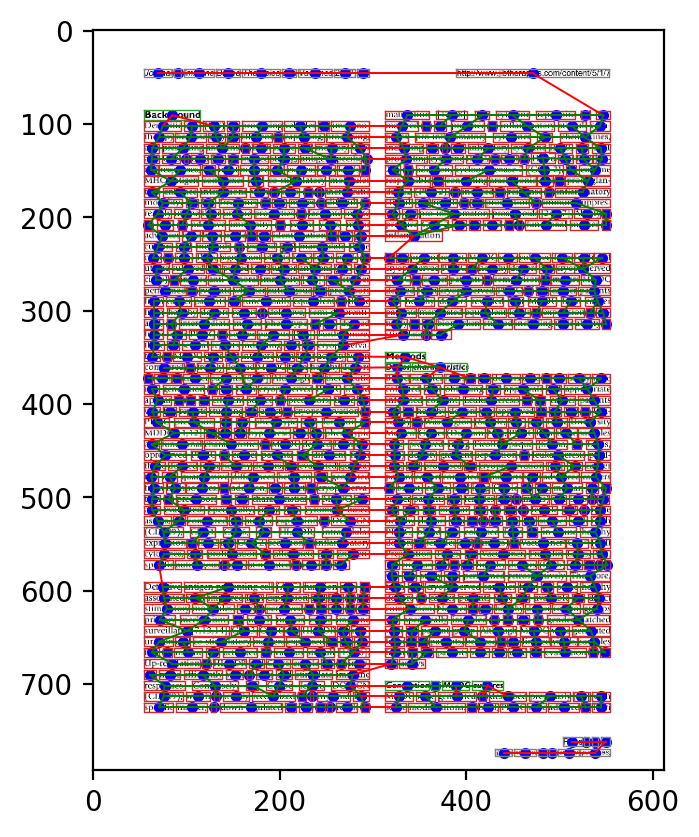

In [38]:
ploter = Ploter(conf={'loger': loger})

sample = train_dataset[101]
sample_name = sample['file_name'] + '.pdf'
print('Файл:', sample_name)
print('Нод:',  sample['N'])
print('Рёбер:', len(sample['inds'][0]) * 2)

# отрисовка через тот же ploter, что и для строк — токенизатор у нас тот же
_, sample_img = pred_train.get_json_and_img(Path(train_dataset_path) / sample_name)
ploter.set_dpi(200)
ploter.plot_img(sample_img)
ploter.plot_tokens(tokenizer, sample, markup=True)

## Параметры модели (type = base)

Параметры скопированы из `start.py` для `type_model == 'base'`.
`node_featch=15`, `edge_featch=4` — определяются токенизатором,
не зависят от того, рисуем мы по строкам или по словам.

In [8]:
model_name = str(Path('words2regionsGLAM').absolute())
model_params  = {
        "node_block": { # Первый слой содержит число features
            "linear_pred": [
                {"in": 15, "out": 256, "activation": "gelu"},
                {"in": 256, "out": 128, "activation": "gelu"},
            ],
            "gnn": [
                ("tag", {"batch_norm": True, "concat": True,
                         "in":128,  "in_gnn":256, "out_gnn":128, 
                         "gnn_activation":"gelu", "activation":"gelu", "K":3}), # Еще есть concat с прошлым слоем
                ("tag", {"batch_norm": False,"concat": True,
                         "in":128+128, "in_gnn":256, "out_gnn":128, 
                         "gnn_activation":"gelu", "activation":"gelu", "K":3}),
                    ],
            # "linear_post": [ # PRED похож на POST
            #     {"in": 128+128+128, "out": 256, "activation": "gelu"},
            #     {"in": 256, "out": 128, "activation": "gelu"},
            #     {"in": 128, "out": 32, "activation": "gelu"},
            # ]
        },
        "node_classifier_block": {
            "linear_post": [ # Удобно задать MLP как только POST часть
                {"in": 128+128+128, "out": 256, "activation": "gelu"},
                {"in": 256, "out": 128, "activation": "gelu"},
                {"in": 128, "out": 6, "activation": "none"},
            ]
        },
        "post_node_block": {
            "linear_pred": [
                {"in": 128+128+128, "out": 256, "activation": "gelu"},
                {"in": 256, "out": 256, "activation": "gelu"},
                {"in": 256, "out": 128, "activation": "gelu"},
            ],
            "gnn": [
                ("tag", {"batch_norm": True, "concat": True,
                         "in":128,  "in_gnn":256, "out_gnn":128, 
                         "gnn_activation":"gelu", "activation":"gelu", "K":3}), # Еще есть concat с прошлым слоем
                ("tag", {"batch_norm": False,"concat": True,
                         "in":128+128, "in_gnn":256, "out_gnn":128, 
                         "gnn_activation":"gelu", "activation":"gelu", "K":3}),
                    ],
            "linear_post": [ # PRED похож на POST
                {"in": 128+128+128, "out": 256, "activation": "gelu"},
                {"in": 256, "out": 128, "activation": "gelu"},
                {"in": 128, "out": 128, "activation": "gelu"},
            ]
        }, # НЕ ОБЯЗАТЕЛЬНЫЙ
        # "conjugate_edge_block": {}, # НЕ ОБЯЗАТЕЛЬНЫЙ
        "edge_classifier_block": {
             "linear_post": [ # Удобно задать MLP как только POST часть
                {"in": 2*(128+15)+4, "out": 256, "activation": "gelu"},
                {"in": 256, "out": 64, "activation": "gelu"},
                {"in": 64, "out": 1, "activation": "none"},
            ]
        },
        "epochs" : 20,
        "batch_size"  : 64,
        "learning_rate" : 0.001,
        "seg_k"  : 0.5,
        "save_frequency": 5,
        "loss_params" : {
            "edge_coef": 0.8,
            "node_coef": 0.2
        },
}

model_params['node_classifier_block']['linear_post'][-1]['activation'] = "none"
model_params['edge_classifier_block']['linear_post'][-1]['activation'] = "none"





## Дисбаланс классов

In [9]:
dataset = train_dataset
dataset.train()

node_imbalance, edge_imbalance = calculate_imbalance(dataset)
model_params['loss_params']['node_imbalance'] = node_imbalance
model_params['loss_params']['edge_imbalance'] = edge_imbalance

In [10]:
model_name

'/home/daniil/disk01_1TB/sources/programs/rows2regionsGLAM/experiments/words/words2regionsGLAM'

## Обучение модели

Тот же `Trainer` и `start_train`, что и в `start.py` (`fun_train_model_with_param`).
Имя файла модели — отдельное (`*_words`), чтобы не затирать чекпоинт версии по строкам.

In [11]:
if not Path(model_name).exists():
    model, num_restart = get_model(model_params, model_name)
    model_params['restart_num'] =  num_restart
    loss = get_loss(model_params['loss_params'])
    trainer = Trainer(model=model, dataset=dataset, loss=loss, train_param=model_params, loger=loger)
    trainer.start_train()
    model = trainer.model
    save_model(model, model_name)


            DATASET INFO:
            count row: 9998
            first: dict_keys(['N', 'X', 'Y', 'inds', 'true_edges', 'true_nodes', 'sp_A', 'file_name'])
            	 A:torch.Size([844, 844])
            	 nodes_feature:torch.Size([844, 15])
            	 edges_feature:torch.Size([1249, 4])
            	 true_edges:torch.Size([1249])
            end:dict_keys(['N', 'X', 'Y', 'inds', 'true_edges', 'true_nodes', 'sp_A', 'file_name'])
            	 A:torch.Size([568, 568])
            	 nodes_feature:torch.Size([568, 15])
            	 edges_feature:torch.Size([694, 4])
            	 true_edges:torch.Size([694])
        node_block:	{'linear_pred': [{'in': 15, 'out': 256, 'activation': 'gelu'}, {'in': 256, 'out': 128, 'activation': 'gelu'}], 'gnn': [('tag', {'batch_norm': True, 'concat': True, 'in': 128, 'in_gnn': 256, 'out_gnn': 128, 'gnn_activation': 'gelu', 'activation': 'gelu', 'K': 3}), ('tag', {'batch_norm': False, 'concat': True, 'in': 256, 'in_gnn': 256, 'out_gnn': 128, 'gnn_a

/home/daniil/disk01_1TB/sources/programs/PageR/env/lib/python3.13/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/daniil/disk01_1TB/sources/programs/PageR/env/lib/python3.13/site-packages/torch_geometric/utils/_spmm.py:71: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:49.)
  src = src.to_sparse_csr()


Время обучения batch'а 1.43 сек                                   
========== EPOCH #1 ========== (0.1285/0.0676)                    
Время обучения epoch 150.29 сек
========== EPOCH #2 ========== (0.0643/0.0544)                    
========== EPOCH #3 ========== (0.0559/0.0470)                    
========== EPOCH #4 ========== (0.0479/0.0413)                    
========== EPOCH #6 ========== (0.0396/0.0364)                    
========== EPOCH #7 ========== (0.0359/0.0348)                    
========== EPOCH #8 ========== (0.0356/0.0352)                    
46.88 % Batch loss=0.0392                                         

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



========== EPOCH #16 ========== (0.0251/0.0282)                   
========== EPOCH #17 ========== (0.0243/0.0278)                   
========== EPOCH #18 ========== (0.0237/0.0270)                   
========== EPOCH #19 ========== (0.0225/0.0267)                   
75.00 % Batch loss=0.0282                                         

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



## Тестирование модели

Точная копия `fun_test_model_with_param` из `start.py` для `type_model == 'base'`:
* для base включаем `sigmoidEdge = True`;
* собираем `Rows2Regions` поверх обученной модели и того же токенизатора;
* `Tester` использует `pred=test_dataset.pred` — а это наш `WordPredProcessor`,
  поэтому конвертация PDF → граф на тесте тоже идёт по словам.

In [16]:
def get_result():
    tmp_rez = Path(model_name+'_res.txt')
    if tmp_rez.exists():
        with open(tmp_rez, 'r') as f:
            rez = json.load(f)
        return rez
        
    model_params['node_classifier_block']['linear_post'][-1]['activation'] = "softmax"
    model_params['edge_classifier_block']['linear_post'][-1]['activation'] = "sigmoid"
    
    
    model, _ = get_model( model_params, model_name)
    
    model_id2name = train_dataset.coco_manager.classes
    dataset_name2id = {val:key for key, val in model_id2name.items()}
    pipeline = Pipeline(pred=pred_test, model=model, dataset_name2id=dataset_name2id, model_id2name=model_id2name)
    tester = Tester(pipeline=pipeline, dataset=test_dataset, loger=loger)
    tester.calculate()
    grid_cls, map_cls = tester.get_results()
    return {**grid_cls, **map_cls}

In [40]:
result = get_result()
result

/home/daniil/disk01_1TB/sources/programs/PageR/env/lib/python3.13/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/daniil/disk01_1TB/sources/programs/PageR/env/lib/python3.13/site-packages/torch/nn/modules/module.py:1779: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


0.50 %

/home/daniil/disk01_1TB/sources/programs/PageR/env/lib/python3.13/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/daniil/disk01_1TB/sources/programs/PageR/env/lib/python3.13/site-packages/torch/nn/modules/module.py:1779: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


1.00 %

/home/daniil/disk01_1TB/sources/programs/PageR/env/lib/python3.13/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/daniil/disk01_1TB/sources/programs/PageR/env/lib/python3.13/site-packages/torch/nn/modules/module.py:1779: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


...

/home/daniil/disk01_1TB/sources/programs/PageR/env/lib/python3.13/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/daniil/disk01_1TB/sources/programs/PageR/env/lib/python3.13/site-packages/torch/nn/modules/module.py:1779: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


99.50 %

/home/daniil/disk01_1TB/sources/programs/PageR/env/lib/python3.13/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/daniil/disk01_1TB/sources/programs/PageR/env/lib/python3.13/site-packages/torch/nn/modules/module.py:1779: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


100.00 %

{'threshold_0.5 (0)': np.float64(0.0),
 'threshold_0.95 (0)': np.float64(0.0),
 'threshold_0.5 (1)': np.float64(0.46840204356311843),
 'threshold_0.95 (1)': np.float64(0.4495606590704182),
 'threshold_0.5 (2)': np.float64(0.5437051363669011),
 'threshold_0.95 (2)': np.float64(0.5388277914895562),
 'threshold_0.5 (3)': np.float64(0.5850963203463203),
 'threshold_0.95 (3)': np.float64(0.5309051226551227),
 'threshold_0.5 (4)': np.float64(0.6966948051948052),
 'threshold_0.95 (4)': np.float64(0.6637460317460318),
 'threshold_0.5 (5)': np.float64(0.5390625),
 'threshold_0.95 (5)': np.float64(0.5160625),
 'threshold_0.5 (all)': np.float64(0.6131902655405802),
 'threshold_0.95 (all)': np.float64(0.5466907892947961),
 'name': 'mAP@IoU[0.50:0.95]',
 'mAP (all)': 0.13804645836353302,
 'mAP (seg)': 0.30863967537879944,
 'mAP (other)': -1.0,
 'mAP (text)': 0.3612305223941803,
 'mAP (title)': 0.2159697562456131,
 'mAP (list)': 0.030404793098568916,
 'mAP (table)': 0.07631085067987442,
 'mAP (figur

In [41]:
print('mAP:')
for k, v in map_cls.items():
    print(f'  {k}: {v}')
print()
print('Grid:')
for k, v in grid_cls.items():
    print(f'  {k}: {v}')

mAP:


NameError: name 'map_cls' is not defined

## Сводный результат (как `fun_result_to_row` в start.py)

## Опционально: визуализация регионов, найденных моделью на одном тестовом файле

/home/daniil/disk01_1TB/sources/programs/PageR/env/lib/python3.13/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)


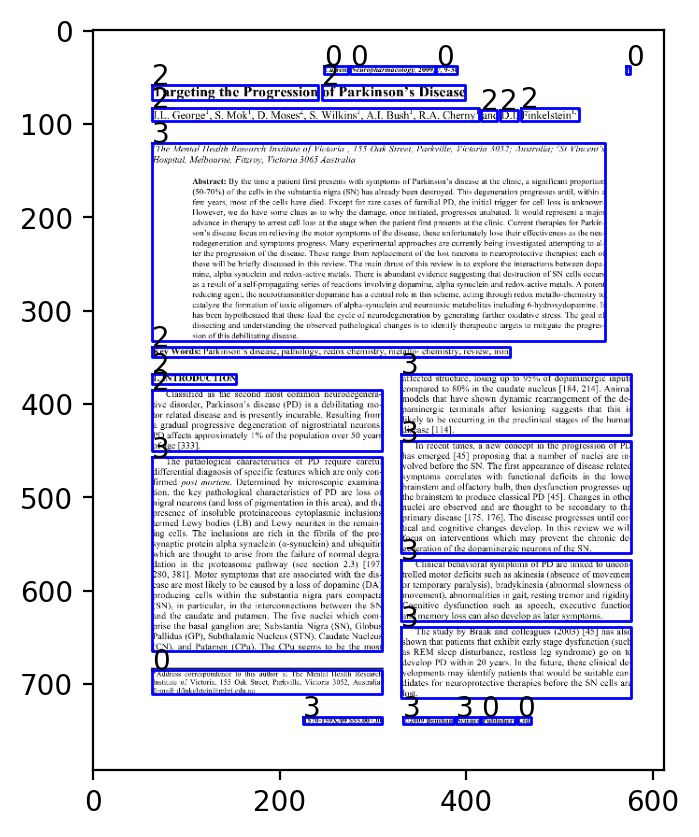

In [46]:
test_dataset.train()
sample_test = test_dataset[5]
sample_test_name = Path(test_dataset_path) /(sample_test['file_name'] + '.pdf')
words_json, sample_img = pred_test.get_json_and_img( sample_test_name)

model_id2name = train_dataset.coco_manager.classes
dataset_name2id = {val:key for key, val in model_id2name.items()}

pipeline = Pipeline(pred=pred_test, model=model.cpu(), dataset_name2id=dataset_name2id, model_id2name=model_id2name)
regions = pipeline(sample_test_name)
ploter.set_dpi(200)
ploter.plot_img(sample_img)
for reg in regions['regions']:
    seg = ImageSegment(dict_2p=reg['segment'])
    seg.plot(text=reg['label'])